In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
metrics = pd.read_csv('metrics.csv', parse_dates=['timestamp'])

# Convert timestamps to milliseconds relative to first row
metrics['timestamp'] = metrics['timestamp'].astype('float64')
metrics["timestamp_ms"] = (metrics["timestamp"] - metrics["timestamp"].iloc[0]) * 1000

# Optional: drop original timestamp if you only want ms
metrics = metrics.drop(columns=["timestamp"])

# Convert pid from int to string for better plotting
metrics['pid'] = metrics['pid'].astype(str)
metrics.head(10)

C:\Users\mario\AppData\Local\Temp\ipykernel_36588\1932698133.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  metrics = pd.read_csv('metrics.csv', parse_dates=['timestamp'])


,service_name,pid,cpu_percent,memory_mb,timestamp_ms
0,unknown,14128,0.0,38.398438,0.000000
1,unknown,37780,0.0,64.195312,108.126163
2,unknown,37992,0.0,44.207031,209.567308
3,recommender,41944,0.0,145.378906,310.903072
4,monitoring,54792,0.0,68.414062,412.358522
5,unknown,59576,0.0,86.023438,513.642073
6,ratings,68832,0.0,81.062500,615.235329
7,unknown,14128,0.0,38.398438,1219.104052
8,unknown,37780,0.0,64.195312,1321.178198
9,unknown,37992,0.0,44.207031,1422.252893


In [11]:
# Remove pids with only 0.0 cpu percent
non_zero_pids = metrics[metrics['cpu_percent'] > 0]['pid'].unique()
metrics = metrics[metrics['pid'].isin(non_zero_pids)]

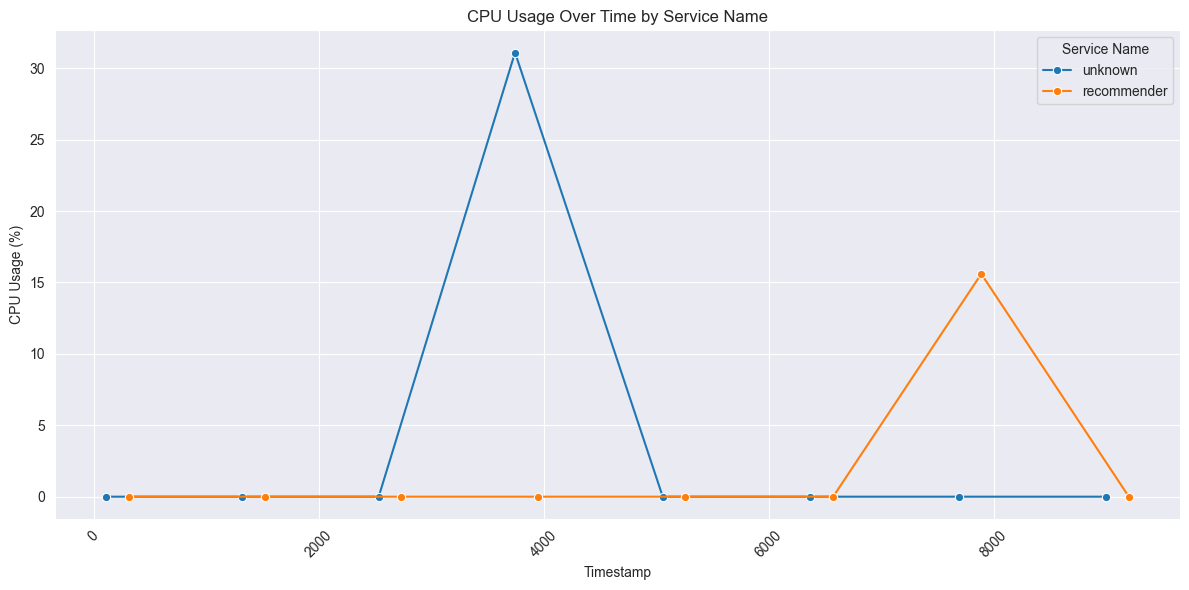

In [13]:
# Plot CPU over time per process ID as a line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=metrics, x='timestamp_ms', y='cpu_percent', hue='service_name', marker='o')
plt.title('CPU Usage Over Time by Service Name')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.legend(title='Service Name')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
